In [1]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives
)
from ipywidgets import widgets, interact


#Solver for Mac
from pymatsolver import Mumps


### Geological Figure of Uranium Ore Body

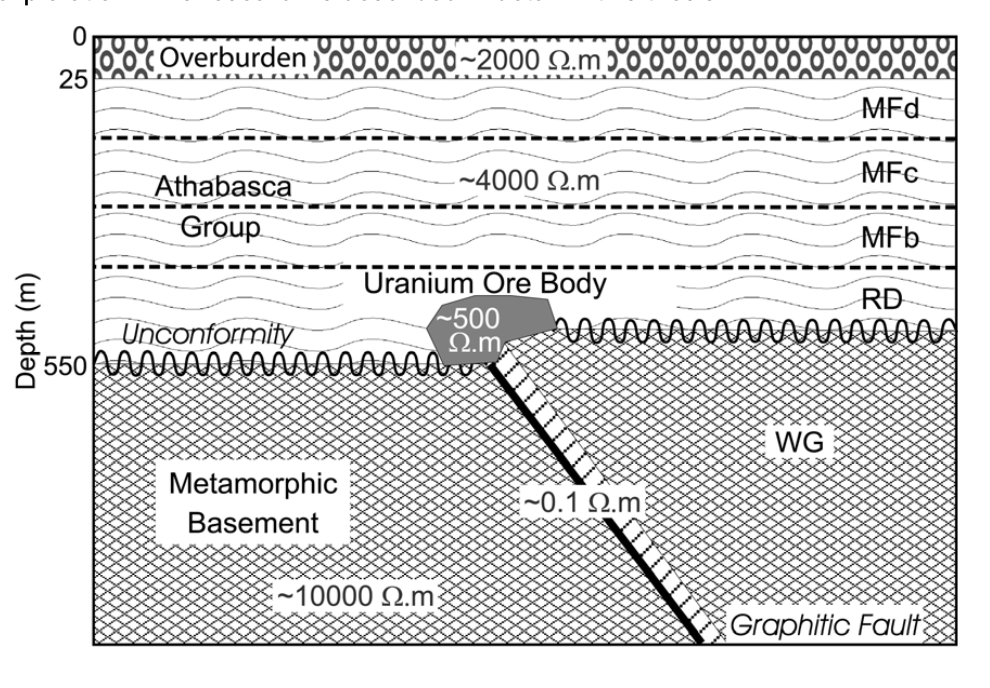

### Defining Properties and Plotting Layer Model

Text(0.5, 1.0, 'Depth vs. Sigma')

<Figure size 1000x500 with 0 Axes>

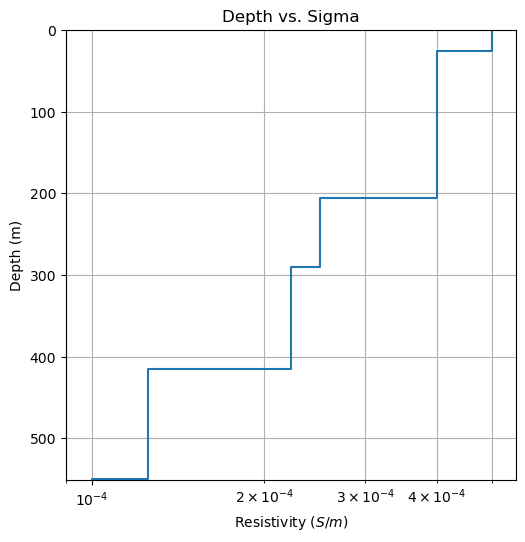

In [2]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 135,1]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data


#Plotting 1D Layer Model for visualization
fig = plt.figure(figsize=(10, 5))

ax1 = plot_1d_layer_model(layer_thicknesses, sigma) # figure has base value at log plot
ax1.grid(which="both")
ax1.set_xlabel(r"Resistivity ($S/m$)")
ax1.set_title('Depth vs. Sigma')


### Setting up 1D MT Simulation

In [3]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 135,1]) #Thicknesses were obtained from Tuncer, pg. 16 # The last thickness is only symbolic and is dropped later on... ie. Halfspace
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data

#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304

#Setting up mesh
mesh = TensorMesh([layer_thicknesses], origin="0")

############

wire_map = maps.Wires(("sigma", mesh.nC), ("t", mesh.nC - 1)) #Not really sure what this does yet...
sigma_map = maps.ExpMap(nP=mesh.nC) * wire_map.sigma
layer_map = maps.ExpMap(nP=mesh.nC - 1) * wire_map.t


model_mapping = maps.IdentityMap(nP=len(sigma))

#Setting up RX locations 
rx_loc = np.array([[0.0]]) 

receivers_list = [
    nsem.receivers.Impedance(rx_loc, orientation="xy", component="apparent_resistivity"),
    nsem.receivers.Impedance(rx_loc, orientation="xy", component="phase"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq))

survey = nsem.survey.Survey(source_list)

simulation = nsem.simulation_1d.Simulation1DRecursive(
    survey=survey, 
    sigmaMap=sigma_map,
    thicknessesMap=layer_map,
)

true_model = np.r_[np.log(sigma), np.log(layer_thicknesses[:-1])]

dpred = simulation.dpred(true_model)


In [12]:
#Code Inspired from https://github.com/simpeg-research/earthscope-mt-course/blob/2024/notebooks/simpeg/3_1d_forward_modelling.ipynb
#micmitch github

import matplotlib.gridspec as gridspec

def calculate_response(rho1, rho2, rho3, rho4, rho5, rho6, t1, t2, t3, t4, t5):
    model = np.log(np.r_[1./rho1, 1./rho2, 1./rho3, 1./rho4, 1./rho5, 1./rho6,
                         t1, t2, t3, t4, t5])
    pred = simulation.dpred(model)
    return pred

def plot_results(rho1, rho2, rho3, rho4, rho5, rho6, t1, t2, t3, t4, t5, add_noise, rerr_amp, floor_phase, plot_option):

    pred = calculate_response(rho1, rho2, rho3, rho4, rho5, rho6, t1, t2, t3, t4, t5)
    amp = pred.reshape((len(frequencies), 2))[:, 0]
    phase = pred.reshape((len(frequencies), 2))[:, 1]

    if add_noise:
        noise = np.c_[np.random.randn(amp.size) * rerr_amp * abs(amp),np.random.randn(amp.size) * floor_phase].flatten()
        pred += noise
    fig = plt.figure(figsize=(16, 5))
    gs = gridspec.GridSpec(1, 5, figure=fig)

    ax0 = fig.add_subplot(gs[0, 0])
    layer_thicknesses = np.array([t1, t2, t3, t4, t5])
    rho = np.r_[rho1, rho2, rho3, rho4, rho5, rho6]
    plot_1d_layer_model(layer_thicknesses, rho, ax=ax0, color="k", **{'label': 'True'})
    ax0.set_xlabel("Resistivity ($\Omega$m)")
    ax0.set_xlim(1e3, 10000)

    ax = fig.add_subplot(gs[0, 2:])
    if (plot_option == 'app_res') or (plot_option == 'both'):
        ax.loglog(frequencies, pred.reshape((len(frequencies), 2))[:, 0],
                  color='C0', label='AppRes.', lw=3)

    if (plot_option == 'phase') or (plot_option == 'both'):
        ax.loglog(frequencies[0], pred.reshape((len(frequencies), 2))[0, 0],
                  color='C1', label='Phase')
        ax_1 = ax.twinx()
        ax_1.plot(frequencies, pred.reshape((len(frequencies), 2))[:, 1],
                  color='C1', lw=3)
        ax_1.set_ylim(0, 90)
        ax_1.set_ylabel("Phase ($\degree$)")

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylim(1, 10000)
    ax.grid(True, which='both', alpha=0.5)
    ax.set_ylabel("Apparent resistivity ($\Omega$m)")
    ax.legend(bbox_to_anchor=(-0.1, 1))
    plt.show()

### MT Responses

In [13]:
Q = interact(
    plot_results,
    rho1=widgets.FloatLogSlider(base=10, value=2000, min=0, max=4, continuous_update=True, description="$\\rho_1$"),
    rho2=widgets.FloatLogSlider(base=10, value=2500, min=0, max=4, continuous_update=True, description="$\\rho_2$"),
    rho3=widgets.FloatLogSlider(base=10, value=4000, min=0, max=4, continuous_update=True, description="$\\rho_3$"),
    rho4=widgets.FloatLogSlider(base=10, value=4500, min=0, max=4, continuous_update=True, description="$\\rho_4$"),
    rho5=widgets.FloatLogSlider(base=10, value=8000, min=0, max=4, continuous_update=True, description="$\\rho_5$"),
    rho6=widgets.FloatLogSlider(base=10, value=10000, min=0, max=4, continuous_update=True, description="$\\rho_6$"),
    t1=widgets.FloatLogSlider(base=10, value=25, min=0, max=3, continuous_update=True, description="$t_1$"),
    t2=widgets.FloatLogSlider(base=10, value=180, min=0, max=3, continuous_update=True, description="$t_2$"),
    t3=widgets.FloatLogSlider(base=10, value=85, min=0, max=3, continuous_update=True, description="$t_3$"),
    t4=widgets.FloatLogSlider(base=10, value=125, min=0, max=3, continuous_update=True, description="$t_4$"),
    t5=widgets.FloatLogSlider(base=10, value=135, min=0, max=3, continuous_update=True, description="$t_5$"),
    add_noise=widgets.Checkbox(),
    rerr_amp=widgets.FloatText(value=0.1),
    floor_phase=widgets.FloatText(value=2),
    plot_option=widgets.RadioButtons(options=['app_res', 'phase', 'both'])
)
Q

interactive(children=(FloatLogSlider(value=2000.0, description='$\\rho_1$'), FloatLogSlider(value=2500.0, desc…

<function __main__.plot_results(rho1, rho2, rho3, rho4, rho5, rho6, t1, t2, t3, t4, t5, add_noise, rerr_amp, floor_phase, plot_option)>